In [2]:
'''

Descriptive Analytics for Numerical Columns
●	Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
●	Steps:
	Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	Identify numerical columns in the dataset.
	Calculate the mean, median, mode, and standard deviation for these columns.
	Provide a brief interpretation of these statistics.

'''

'\n\nDescriptive Analytics for Numerical Columns\n●\tObjective: To compute and analyze basic statistical measures for numerical columns in the dataset.\n●\tSteps:\n\tLoad the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).\n\tIdentify numerical columns in the dataset.\n\tCalculate the mean, median, mode, and standard deviation for these columns.\n\tProvide a brief interpretation of these statistics.\n\n'

In [3]:
import pandas as pd

In [4]:
from google.colab import files
uploaded = files.upload()  #Uploading the .csv/data file

Saving sales_data_with_discounts.csv to sales_data_with_discounts.csv


In [5]:
df = pd.read_csv("sales_data_with_discounts.csv") #Reading the file to dataframe
print(df.head())
print('\n')
print(df.info())  # Checking for the numerical columns


         Date       Day  SKU City  Volume       BU  Brand       Model  \
0  01-04-2021  Thursday  M01    C      15  Mobiles  RealU       RU-10   
1  01-04-2021  Thursday  M02    C      10  Mobiles  RealU   RU-9 Plus   
2  01-04-2021  Thursday  M03    C       7  Mobiles   YouM       YM-99   
3  01-04-2021  Thursday  M04    C       6  Mobiles   YouM  YM-99 Plus   
4  01-04-2021  Thursday  M05    C       3  Mobiles   YouM      YM-98    

   Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      12100             181500          11.654820     21153.498820   
1      10100             101000          11.560498     11676.102961   
2      16100             112700           9.456886     10657.910157   
3      20100             120600           6.935385      8364.074702   
4       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


<class

In [6]:

#Identify numerical columns in the dataset.
df_numeric = df.select_dtypes(include =['int64','float64'])
#df_numeric = df_new[['Volume','Avg Price','Total Sales Value','Discount Rate (%)','Discount Amount','Net Sales Value']]

print("New DataFrame of the numeric values:\n")
print(df_numeric.head())


New DataFrame of the numeric values:

   Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0      15      12100             181500          11.654820     21153.498820   
1      10      10100             101000          11.560498     11676.102961   
2       7      16100             112700           9.456886     10657.910157   
3       6      20100             120600           6.935385      8364.074702   
4       3       8100              24300          17.995663      4372.946230   

   Net Sales Value  
0    160346.501180  
1     89323.897039  
2    102042.089843  
3    112235.925298  
4     19927.053770  


In [7]:
print("Checking for Null columns")
#print(df_numeric.isnull().sum())

if df_numeric.isna().values.sum() > 0:
  print("\nNull column values in the Numeric Dataframe are:\n")
  print(df_numeric.isna().sum())
else:
  print("\nNo null column values in the Numeric Dataframe")

Checking for Null columns

No null column values in the Numeric Dataframe


In [8]:
#print(df_numeric['Volume'].describe())

print("\nThe mean values of all the numeric columns are:")
print(df_numeric.mean(axis = 0))

print("\nThe median values of all the numeric columns are:")
print(df_numeric.median(axis = 0))

print("\nThe standard deviation values of all the numeric columns are:")
print(df_numeric.std(axis = 0))


The mean values of all the numeric columns are:
Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

The median values of all the numeric columns are:
Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

The standard deviation values of all the numeric columns are:
Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


In [9]:
print("\nThe Mean,Median,Mode and stdev values of all the numeric columns are: \n \n")

stats = {}
cmean = 0
cmedian = 0
cstd = 0

for col in df_numeric.columns.tolist():

    cmean = float(df_numeric[col].mean(axis = 0))
    cmedian = df_numeric[col].median(axis = 0)
    cstd = df_numeric[col].std(axis = 0)
    mode_count = df_numeric[col].mode().count()

    #print(f"\nMode for {col} is :{df_numeric[col].mode().count()}")

    if mode_count == 1:
      #print(f"Mode of {col} is: \n{df_numeric[col].mode().values}")
      stats[col] = [round(cmean,2),cmedian,cstd,list(df_numeric[col].mode())]
    elif mode_count == 2:
        #print(f"{col} is Bimodal: \n{df_numeric[col].mode().values}")
        stats[col] = [round(cmean,2),cmedian,cstd,list(df_numeric[col].mode())]
    elif mode_count > 2:
        #print(f"{col} is Multi modal: \n{round(df_numeric[col]).mode().values}")
        stats[col] = [round(cmean,2),cmedian,cstd,'MultiModal']
#print(stats)

df_stats=pd.DataFrame(stats.values(),index=stats.keys(),columns = ['Mean','Median','Stdev','Mode'])
print(df_stats)


The Mean,Median,Mode and stdev values of all the numeric columns are: 
 

                       Mean       Median         Stdev        Mode
Volume                 5.07     4.000000      4.231602         [3]
Avg Price          10453.43  1450.000000  18079.904840  MultiModal
Total Sales Value  33812.84  5700.000000  50535.074173     [24300]
Discount Rate (%)     15.16    16.577766      4.220602  MultiModal
Discount Amount     3346.50   988.933733   4509.902963  MultiModal
Net Sales Value    30466.34  4677.788059  46358.656624  MultiModal


**Interpretation of the above:**

Data looks right skewed for all the columns except the "Discount Rate (%)" column as the Mean > Median, meaning there is a “tail” on the right side of the distribution.
Where as for the Discount Rate (%) column values Mean < Median and hence, the data is left skewed.

All the parameters are Multimodal except for Volume and Total Sales Value.

In [ ]:
'''
Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.'''


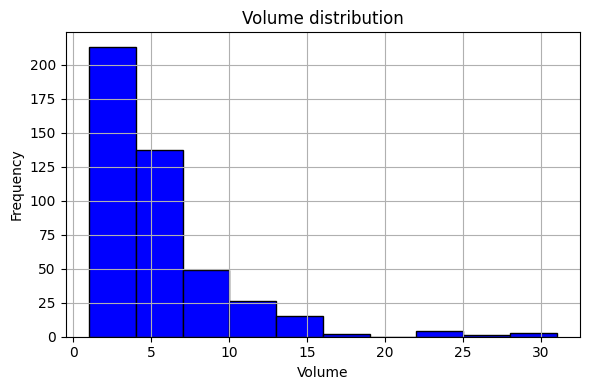

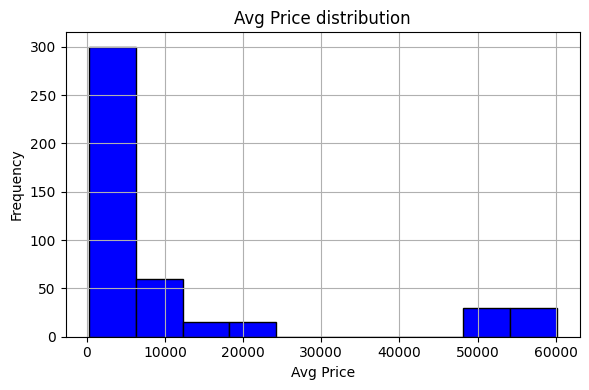

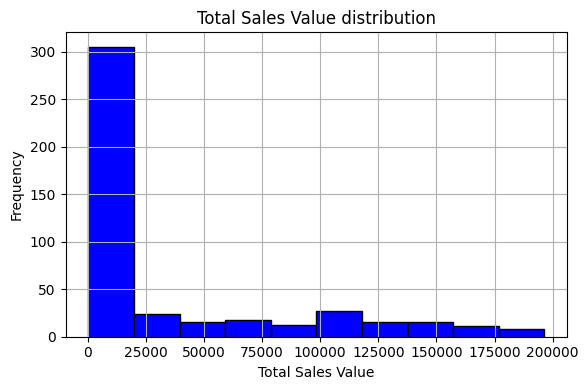

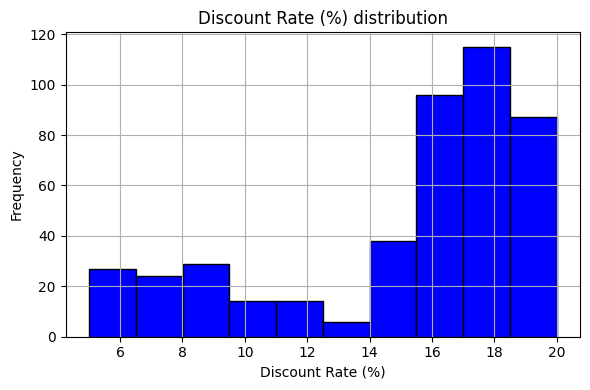

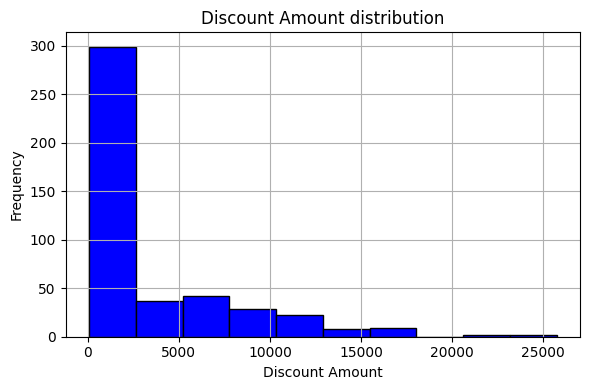

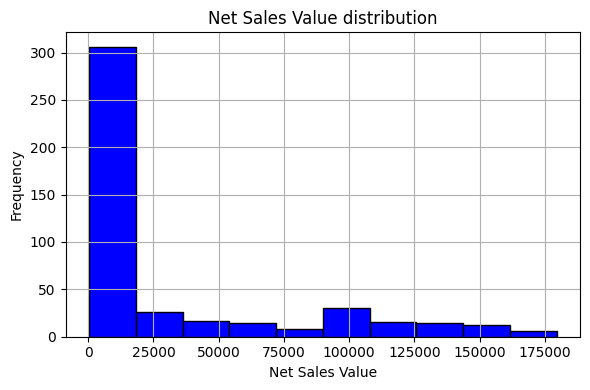

In [40]:
import matplotlib.pyplot as plt

for col in df_numeric.columns.tolist():

    # Add the histogram

    df_numeric[col].hist(figsize=(6,4),edgecolor='black', color='blue') # edge color and color of the bins


    # Add title and axis label
    plt.title(f'{col} distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()


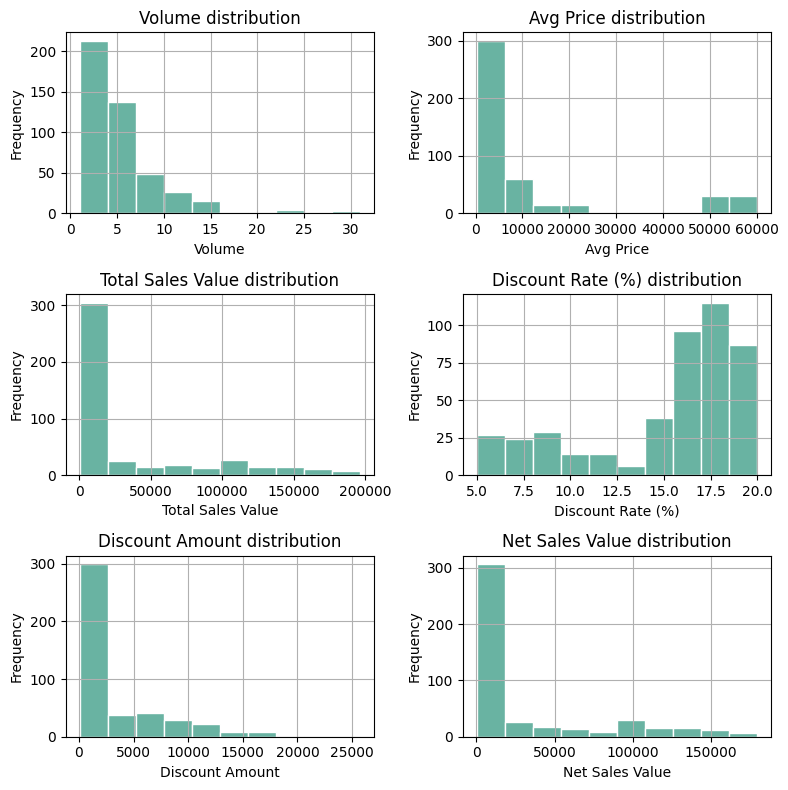

In [142]:
# Initialize  3x2 charts for 6 numeric columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 8))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a histogram
for i, column in enumerate(df_numeric.columns):

    # Add the histogram
    df_numeric[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )

    # Adding title and axis label
    axes[i].set_title(f'{column} distribution')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Adjusting the  layout
plt.tight_layout()

# Show the plot
plt.show()

**Inferences**: The above graphs show that all the numeric columns are right skewed except for the Discount Rate (%) which is left skewed.

In [ ]:
'''
Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.
'''

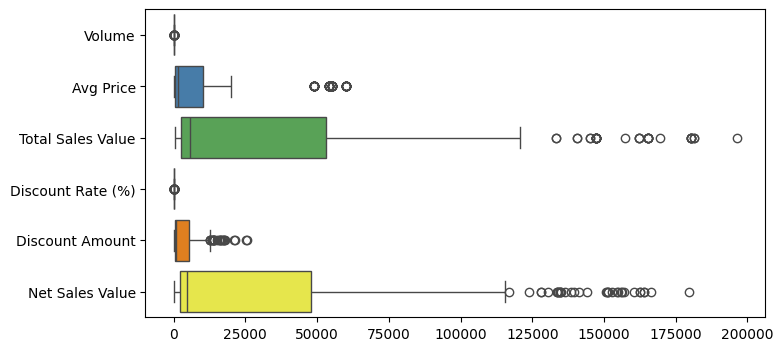

In [80]:
#using seaborn  for boxplot
import seaborn as sns

ax = sns.boxplot(data=df_numeric,orient = 'y',palette = 'Set1')

<Axes: >

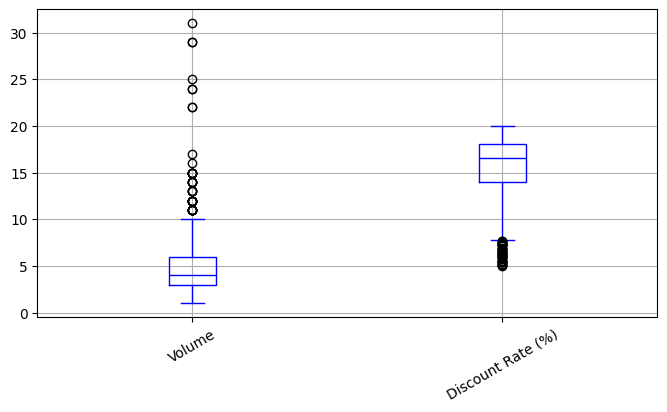

In [85]:
#using matplotlib for boxplot of smaller values of Volume column and Discount Rate (%)
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (8,4)
#df_numeric.boxplot(grid='true', color='blue',fontsize=10, rot=30)
df_numeric.boxplot(column=['Volume','Discount Rate (%)'],grid='true', color='blue',fontsize=10, rot=30)

**Inferences from Box plot:**

All the numeric columns  are Right Skewed, except for the "Discount Rate (%)" column  which is left skewed as clearly seen from the above box plot.

Every Column clealry shows presence of Outliers after the box whiskers'''


In [ ]:
'''
  Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.
'''

In [134]:
import matplotlib.pyplot as plt

df_cat = df.select_dtypes(include =['object'])

df_cat.isna().sum()

df_cat.describe()



,Date,Day,SKU,City,BU,Brand,Model
count,450,450,450,450,450,450,450
unique,15,7,30,1,3,9,30
top,01-04-2021,Thursday,M01,C,Mobiles,Jeera,RU-10
freq,30,90,15,450,150,90,15


Frequency of Date column values


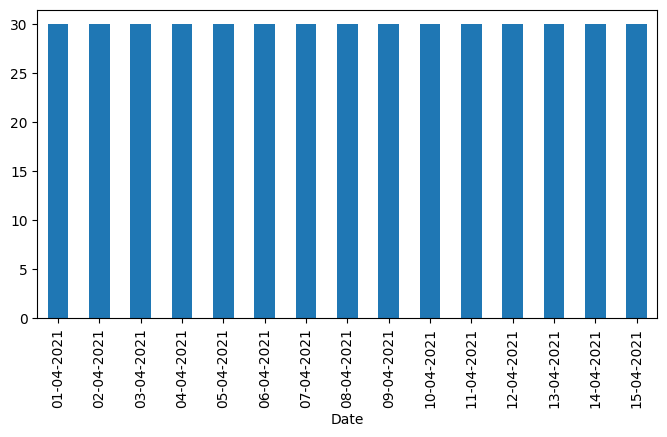

Frequency of Day column values


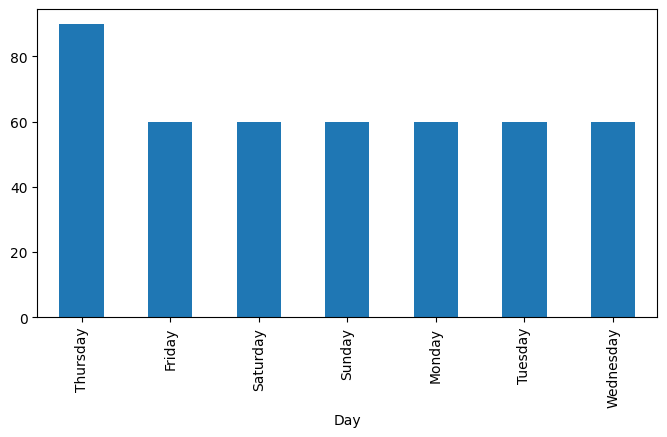

Frequency of SKU column values


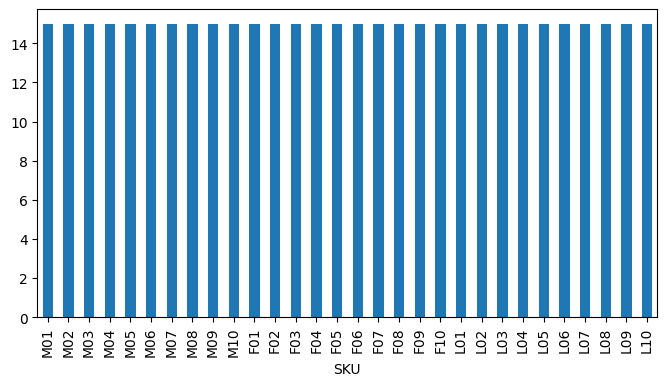

Frequency of City column values


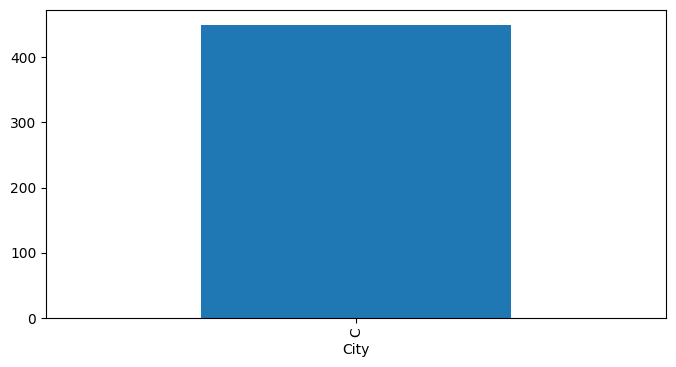

Frequency of BU column values


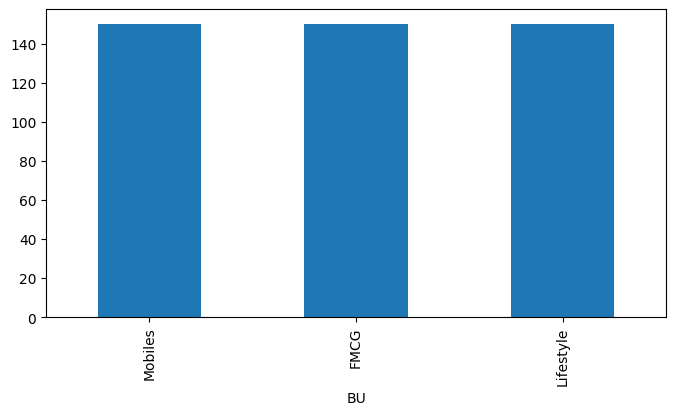

Frequency of Brand column values


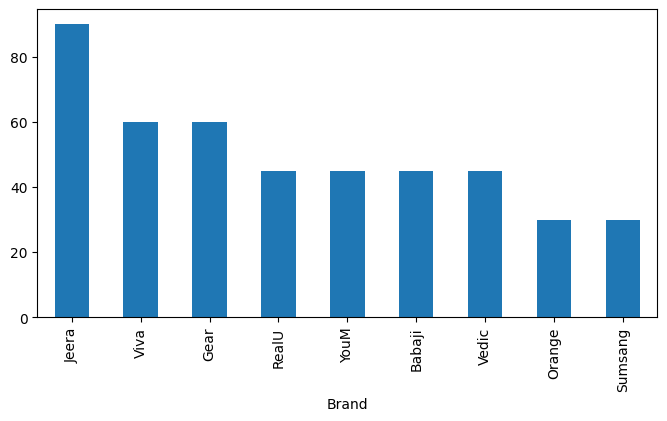

Frequency of Model column values


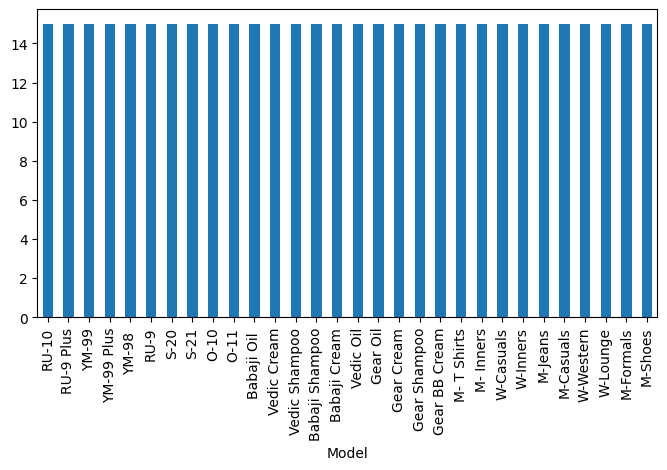

In [145]:

for column_name in df_cat:
    print(f"Frequency of {column_name} column values")
    df_cat[column_name].value_counts().plot(kind='bar')
    plt.show()


***Inferences from the Description and Visualisation of Categorical Columns:***

City - has a Single value of 'C' for all the 450 rows.
Date - has 15 unique values and all have the same frequecy of 30.
Day - has 7 unique values and "Thursday" has the highest frequency of 90 and the other 6 days have frequency of 60.
SKU - Has 30 unique values and all fall under the same frequency.
BU  - Has 3 unique values and all fall under the same frequency.
Brand - has 9 unique values and "Jeera" has the highest frequency of 90 and "Sumsang","Orange" have lowest frequency of 40.
Model - Has 30 unique values and all fall under the same frequency.
